# Twitter Sentiment Analysis — Optimized for Mac
### Speed optimizations: Metal GPU, Mixed Precision, tf.data pipeline, GRU, no recurrent_dropout

In [36]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, LSTM, GRU, Embedding, Dropout, SpatialDropout1D, Bidirectional
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
import re
import string
import warnings
warnings.filterwarnings('ignore')

## ⚡ Speed Optimization Setup

In [2]:
# 1. Enable Metal GPU on Apple Silicon (no-op on Intel Macs)
print('GPUs available:', tf.config.list_physical_devices('GPU'))

# 2. Mixed precision – halves memory, speeds up Metal & CPU
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print('Mixed precision policy:', mixed_precision.global_policy())

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">


## 📥 Load Dataset

In [3]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/narendrafuloria/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/narendrafuloria/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
dataset = pd.read_csv('twitter_training.csv', header=None)
dataset.sample(10)

,0,1,2,3
3823,1861,CallOfDutyBlackopsColdWar,Neutral,This game stinks Jesus Christ
67137,7096,johnson&johnson,Irrelevant,Loiter Squad gave us Negro<unk> you can keep t...
18811,12424,WorldOfCraft,Positive,I'd love to play Romulo from World of Warcraft...
28897,571,ApexLegends,Negative,had the same problem
22979,4337,CS-GO,Neutral,of
21686,4112,CS-GO,Positive,@ FACEIT me and my friends just got a cooldown...
39596,5596,Hearthstone,Neutral,"It's a deck I played in. It's inconsistent, li..."
59615,3418,Facebook,Negative,The sight of racist scv people on facebook thr...
26322,921,AssassinsCreed,Neutral,Get ready for the weekend with our Special . ...
63434,7672,MaddenNFL,Negative,Defense on @ EAMaddenNFL Fuckin Sucks


In [5]:
dataset.rename(columns={1: 'Product', 2: 'Sentiment', 3: 'Text'}, inplace=True)
dataset.drop(columns=0, inplace=True)
dataset.head()

,Product,Sentiment,Text
0,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,Borderlands,Positive,I am coming to the borders and I will kill you...
2,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,Borderlands,Positive,im coming on borderlands and i will murder you...
4,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


## 🏷️ Label Encoding

In [6]:
encoder = LabelEncoder()
dataset['Sentiment'] = encoder.fit_transform(dataset['Sentiment'])
print('Classes:', encoder.classes_)
dataset.head()

Classes: ['Irrelevant' 'Negative' 'Neutral' 'Positive']


,Product,Sentiment,Text
0,Borderlands,3,im getting on borderlands and i will murder yo...
1,Borderlands,3,I am coming to the borders and I will kill you...
2,Borderlands,3,im getting on borderlands and i will kill you ...
3,Borderlands,3,im coming on borderlands and i will murder you...
4,Borderlands,3,im getting on borderlands 2 and i will murder ...


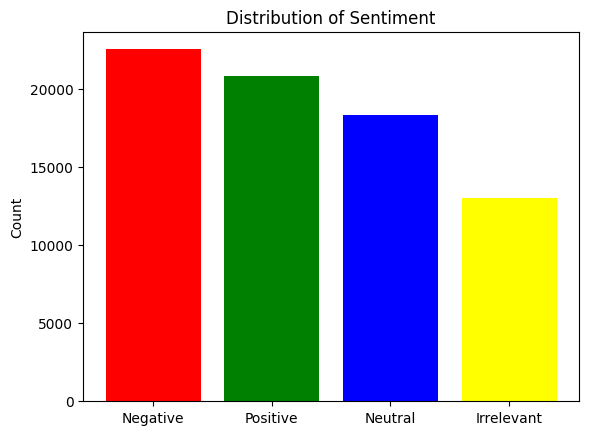

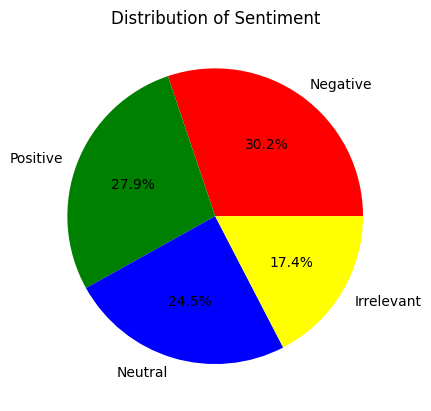

In [7]:
labels = encoder.inverse_transform(dataset['Sentiment'].value_counts().index)

plt.bar(labels, dataset['Sentiment'].value_counts().values, color=['red', 'green', 'blue', 'yellow'])
plt.ylabel('Count')
plt.title('Distribution of Sentiment')
plt.show()

plt.pie(dataset['Sentiment'].value_counts().values, labels=labels,
        colors=['red', 'green', 'blue', 'yellow'], autopct='%1.1f%%')
plt.title('Distribution of Sentiment')
plt.show()

## 📊 EDA

In [10]:
text_data = dataset['Text'].fillna("")

dataset['num_characters'] = text_data.str.len()

dataset['num_words'] = text_data.apply(
    lambda x: len(nltk.word_tokenize(x))
)

dataset['num_sentences'] = text_data.apply(
    lambda x: len(nltk.sent_tokenize(x))
)

dataset[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,74682.000000,74682.000000,74682.000000
mean,107.784406,22.383332,1.927506
std,79.835538,17.215077,1.638201
min,0.000000,0.000000,0.000000
25%,45.000000,9.000000,1.000000
50%,90.000000,18.000000,1.000000
75%,152.000000,31.000000,2.000000
max,957.000000,198.000000,33.000000


In [11]:
# Per-sentiment stats
sentiment_names = {0: 'Irrelevant', 1: 'Negative', 2: 'Neutral', 3: 'Positive'}
for s, name in sentiment_names.items():
    print(f'\n--- {name} ---')
    print(dataset[dataset['Sentiment'] == s][['num_characters', 'num_words', 'num_sentences']].describe())


--- Irrelevant ---
       num_characters     num_words  num_sentences
count    12990.000000  12990.000000   12990.000000
mean       109.947421     22.892687       2.006467
std         79.414339     17.207985       1.733039
min          0.000000      0.000000       0.000000
25%         49.000000     10.000000       1.000000
50%         92.000000     18.000000       1.000000
75%        154.000000     32.000000       2.000000
max        692.000000    198.000000      25.000000

--- Negative ---
       num_characters     num_words  num_sentences
count     22542.00000  22542.000000   22542.000000
mean        110.37734     23.092583       1.801260
std          82.12827     17.450207       1.367706
min           0.00000      0.000000       0.000000
25%          45.00000      9.000000       1.000000
50%          90.00000     19.000000       1.000000
75%         160.00000     33.000000       2.000000
max         727.00000    198.000000      22.000000

--- Neutral ---
       num_characters     n

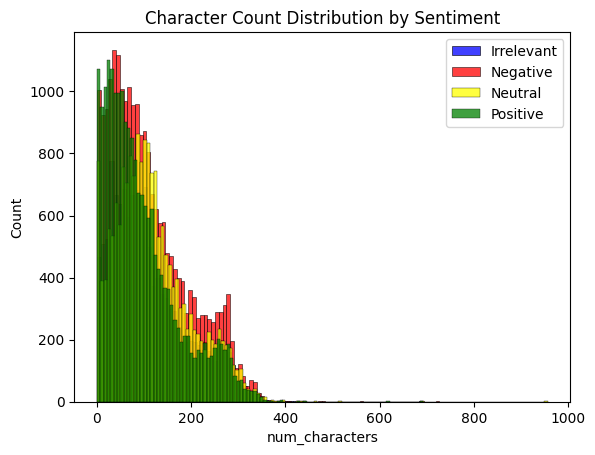

In [12]:
colors = ['blue', 'red', 'yellow', 'green']
for i, col in enumerate(colors):
    sns.histplot(dataset[dataset['Sentiment'] == i]['num_characters'], color=col, label=list(sentiment_names.values())[i])
plt.legend()
plt.title('Character Count Distribution by Sentiment')
plt.show()

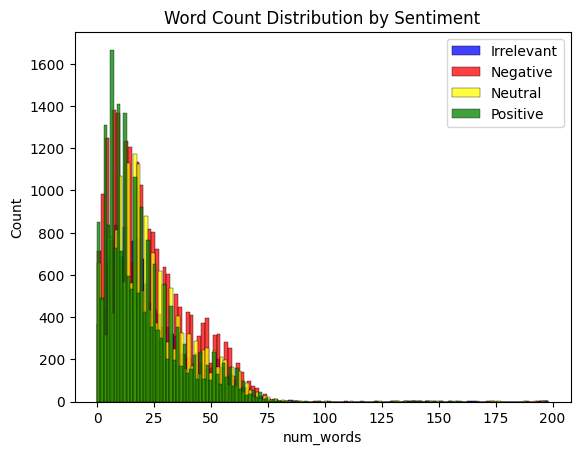

In [13]:
for i, col in enumerate(colors):
    sns.histplot(dataset[dataset['Sentiment'] == i]['num_words'], color=col, label=list(sentiment_names.values())[i])
plt.legend()
plt.title('Word Count Distribution by Sentiment')
plt.show()

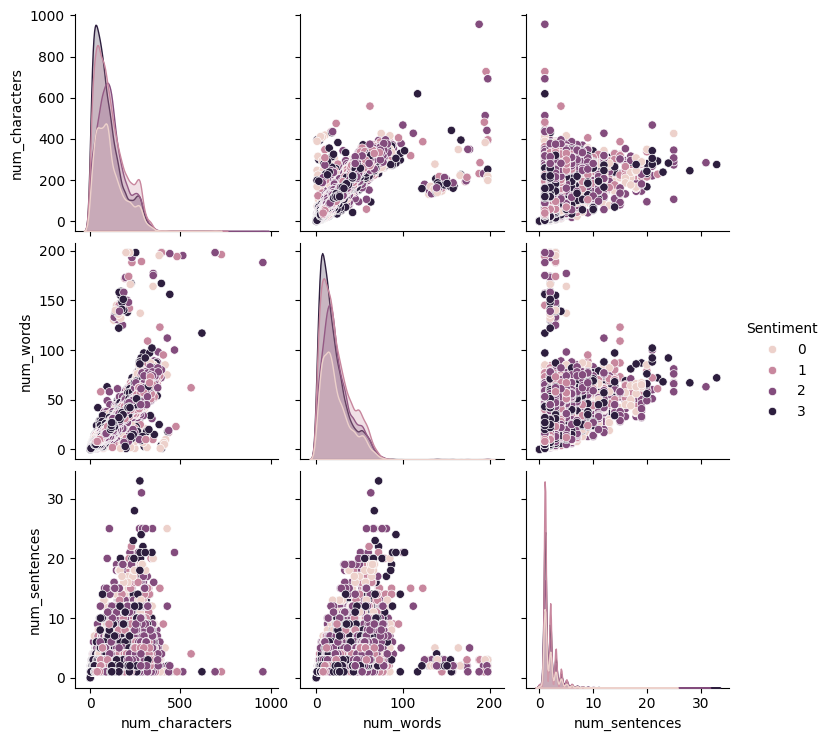

In [14]:
sns.pairplot(dataset, hue='Sentiment')
plt.show()

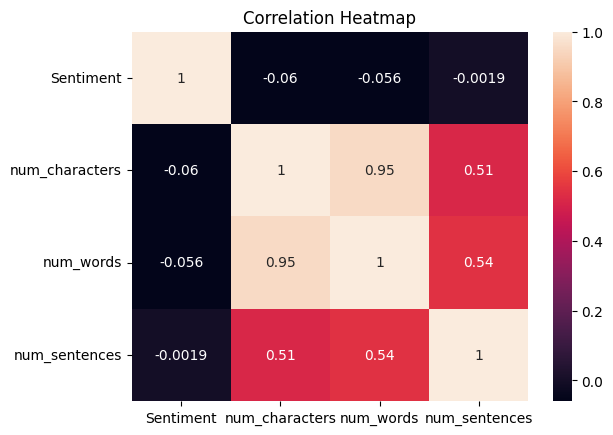

In [15]:
sns.heatmap(dataset.select_dtypes(include=['number']).corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

## 🧹 Data Preprocessing
- Lowercase
- Remove URLs
- Tokenisation
- Remove special characters, stop words & punctuation
- Stemming

In [16]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

nltk.download('stopwords')

ps = PorterStemmer()

def transform_text(text):
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = nltk.word_tokenize(text)
    y = [i for i in text if i.isalnum()]
    y = [i for i in y if i not in stopwords.words('english') and i not in ['@', '#']]
    y = [ps.stem(i) for i in y]
    return ' '.join(y)

dataset['transformed_text'] = dataset['Text'].apply(transform_text)
dataset.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/narendrafuloria/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Product,Sentiment,Text,num_characters,num_words,num_sentences,transformed_text
0,Borderlands,3,im getting on borderlands and i will murder yo...,53,11,1,im get borderland murder
1,Borderlands,3,I am coming to the borders and I will kill you...,51,13,1,come border kill
2,Borderlands,3,im getting on borderlands and i will kill you ...,50,11,1,im get borderland kill
3,Borderlands,3,im coming on borderlands and i will murder you...,51,11,1,im come borderland murder
4,Borderlands,3,im getting on borderlands 2 and i will murder ...,57,13,1,im get borderland 2 murder


## ☁️ Word Clouds

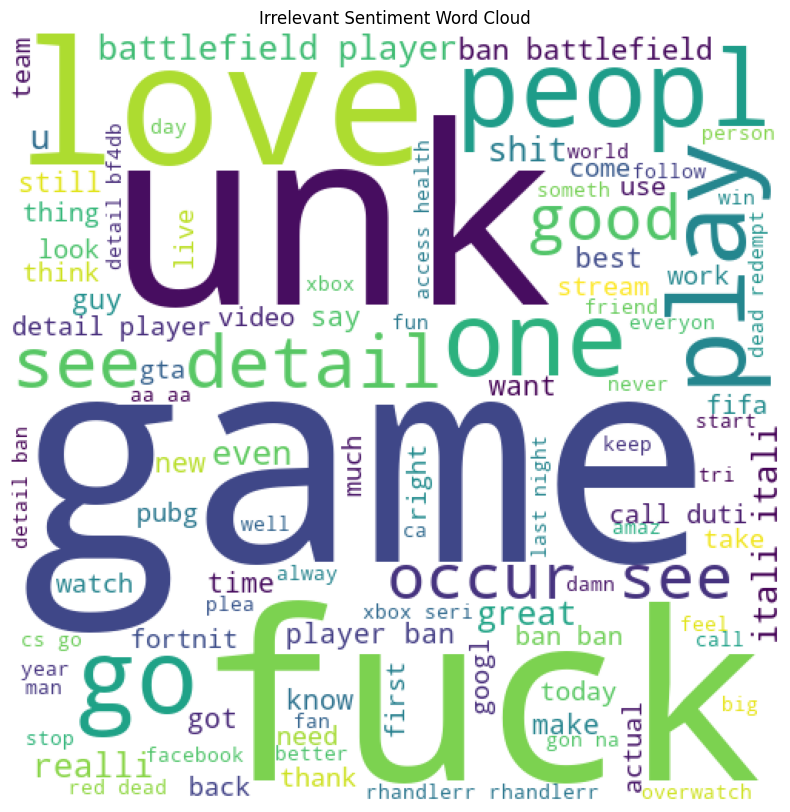

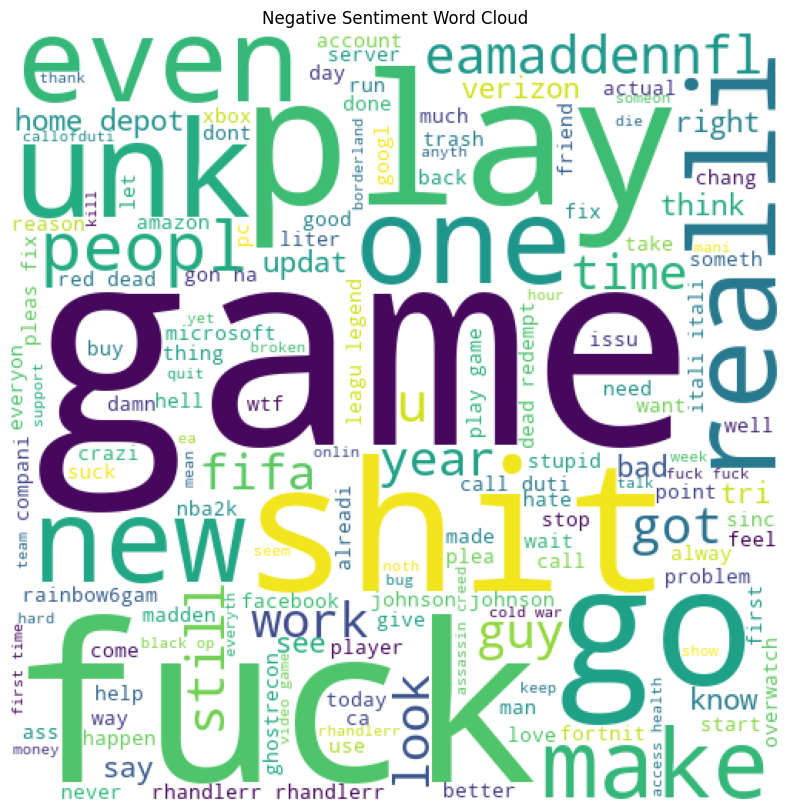

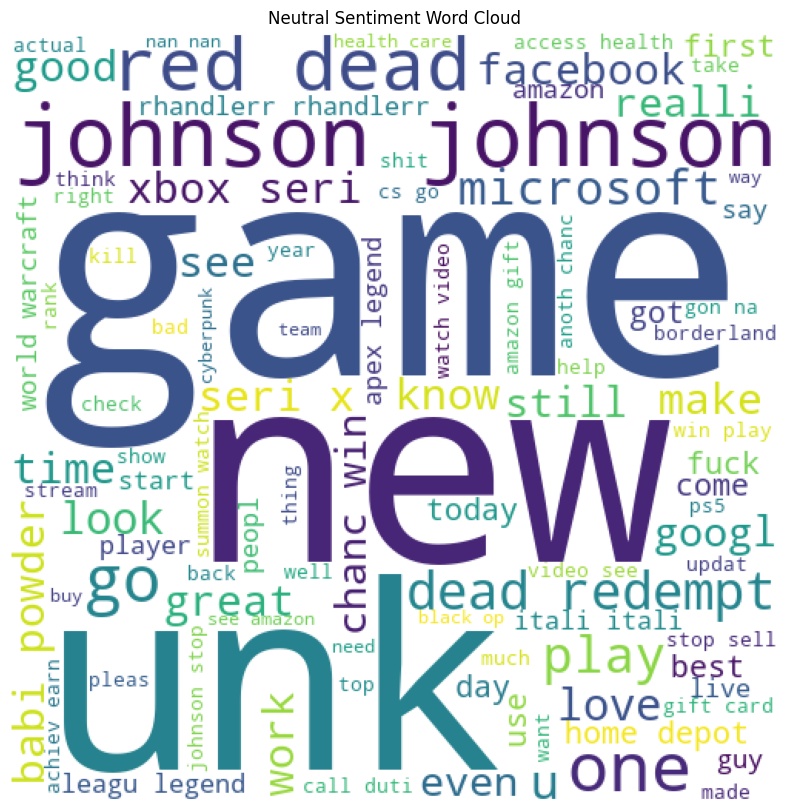

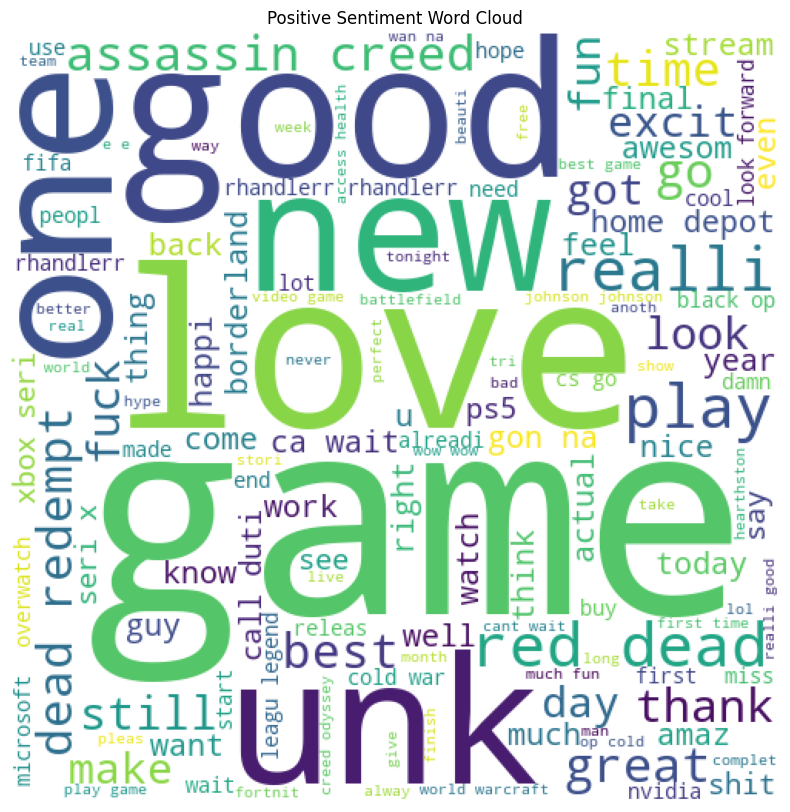

In [17]:
from wordcloud import WordCloud

wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

for s, name in sentiment_names.items():
    cloud = wc.generate(dataset[dataset['Sentiment'] == s]['transformed_text'].str.cat(sep=' '))
    plt.figure(figsize=(10, 10))
    plt.imshow(cloud)
    plt.axis('off')
    plt.title(f'{name} Sentiment Word Cloud')
    plt.show()

## 📈 Most Common Words per Sentiment

In [18]:
from collections import Counter

for s, name in sentiment_names.items():
    corpus = [word for text in dataset[dataset['Sentiment'] == s]['transformed_text'] for word in text.split()]
    print(f'\n--- Top 10 words: {name} ---')
    print(Counter(corpus).most_common(10))


--- Top 10 words: Irrelevant ---
[('game', 1211), ('player', 1128), ('like', 1093), ('see', 1063), ('ban', 948), ('play', 815), ('love', 792), ('go', 778), ('peopl', 777), ('get', 768)]

--- Top 10 words: Negative ---
[('game', 4601), ('fuck', 2476), ('get', 2374), ('play', 2085), ('like', 1695), ('shit', 1543), ('fix', 1454), ('go', 1290), ('make', 1183), ('time', 1137)]

--- Top 10 words: Neutral ---
[('game', 1832), ('johnson', 1819), ('play', 1518), ('2', 1241), ('get', 1200), ('amazon', 1152), ('like', 989), ('one', 881), ('googl', 852), ('new', 850)]

--- Top 10 words: Positive ---
[('game', 3275), ('play', 2549), ('love', 2112), ('good', 1627), ('like', 1465), ('thank', 1310), ('get', 1304), ('realli', 1281), ('new', 1200), ('look', 1195)]


## ✂️ Train / Test Split

In [19]:
data_train, data_test = train_test_split(
    dataset, test_size=0.2, random_state=42, stratify=dataset['Sentiment']
)
print('Train shape:', data_train.shape)
print('Test shape: ', data_test.shape)

Train shape: (59745, 7)
Test shape:  (14937, 7)


## 🔤 Tokenization & Padding

In [26]:
VOCAB_SIZE  = 5000 +1  # +1 for OOV token
MAX_LEN     = 200
OOV_TOKEN   = '<OOV>'
BATCH_SIZE  = 256   # ← bigger batches = better hardware utilization

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(data_train['transformed_text'])  # fit only on train ✓

train_sequences = tokenizer.texts_to_sequences(data_train['transformed_text'])
test_sequences  = tokenizer.texts_to_sequences(data_test['transformed_text'])

X_train = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(test_sequences,  maxlen=MAX_LEN, padding='post', truncating='post')

y_train = data_train['Sentiment'].values
y_test  = data_test['Sentiment'].values

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)

X_train: (59745, 200)
X_test:  (14937, 200)


## ⚡ tf.data Pipeline
> Eliminates Python data-loading bottleneck via `.cache()` + `.prefetch()`

In [27]:
def make_dataset(X, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), reshuffle_each_iteration=True)
    return (
        ds
        .batch(BATCH_SIZE)
        .cache()                        # cache in RAM after first epoch
        .prefetch(tf.data.AUTOTUNE)     # overlap data loading & GPU compute
    )

train_ds = make_dataset(X_train, y_train, shuffle=True)
test_ds  = make_dataset(X_test,  y_test)
print('tf.data pipelines ready ✓')

tf.data pipelines ready ✓


## 🏗️ Model Architecture
> **Key speed changes vs original:**
> - `GRU` instead of `LSTM` (~30% faster, similar accuracy)
> - No `recurrent_dropout` → enables fast CuDNN/Metal optimized kernel
> - `SpatialDropout1D` replaces recurrent dropout for regularization
> - Final Dense uses `float32` for numerical stability with mixed precision

In [39]:
model = Sequential([
    Embedding(VOCAB_SIZE, 128),

    SpatialDropout1D(0.3),

    Bidirectional(LSTM(128, return_sequences=True, dropout=0.3)),
    Bidirectional(LSTM(64, dropout=0.3)),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(4, activation='softmax', dtype='float32')
])

## 🚀 Compile & Train

In [40]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds,    # use test_ds directly (no validation_split with tf.data)
    callbacks=[early_stop]
)

Epoch 1/10


234/234 ━━━━━━━━━━━━━━━━━━━━ 38s 154ms/step - accuracy: 0.5030 - loss: 1.1281 - val_accuracy: 0.6229 - val_loss: 0.9239
Epoch 2/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 35s 151ms/step - accuracy: 0.6492 - loss: 0.8778 - val_accuracy: 0.6691 - val_loss: 0.8274
Epoch 3/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 35s 151ms/step - accuracy: 0.6937 - loss: 0.7835 - val_accuracy: 0.6916 - val_loss: 0.7778
Epoch 4/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 36s 152ms/step - accuracy: 0.7184 - loss: 0.7259 - val_accuracy: 0.7011 - val_loss: 0.7556
Epoch 5/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 36s 153ms/step - accuracy: 0.7356 - loss: 0.6786 - val_accuracy: 0.7108 - val_loss: 0.7337
Epoch 6/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 36s 153ms/step - accuracy: 0.7499 - loss: 0.6420 - val_accuracy: 0.7236 - val_loss: 0.7094
Epoch 7/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 37s 157ms/step - accuracy: 0.7564 - loss: 0.6182 - val_accuracy: 0.7221 - val_loss: 0.7072
Epoch 8/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 35s 151ms/step - accuracy: 0.7654 - loss: 0.5940 - val

## 📉 Training Curves

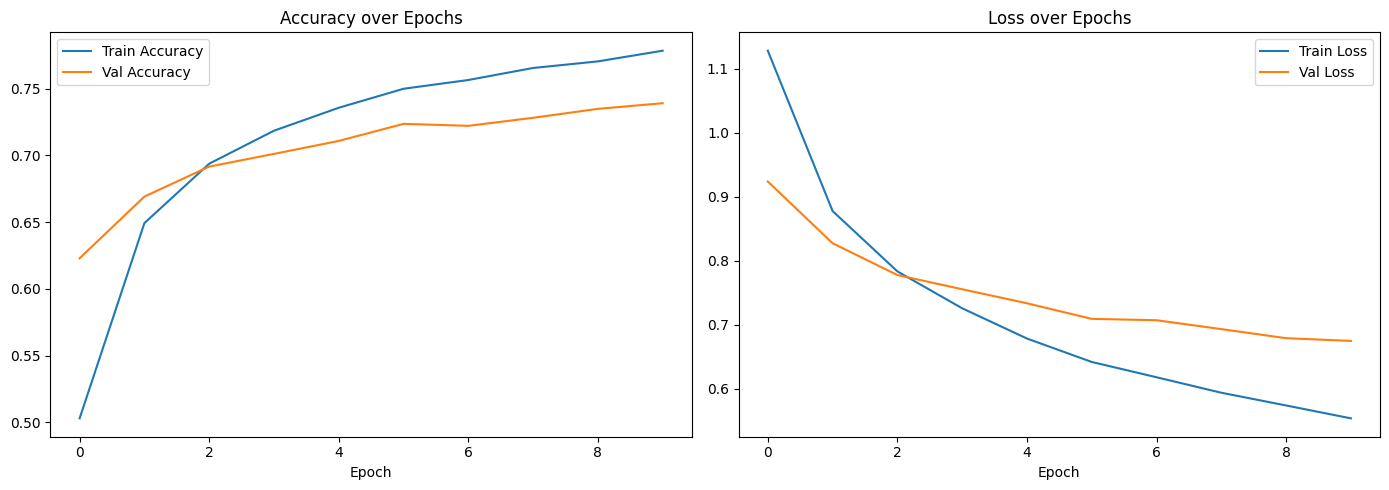

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## ✅ Evaluation

In [42]:
loss, accuracy = model.evaluate(test_ds)
print(f'Test Loss:     {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.7390 - loss: 0.6749
Test Loss:     0.6749
Test Accuracy: 0.7390


In [43]:
y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

467/467 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step
              precision    recall  f1-score   support

  Irrelevant       0.71      0.65      0.68      2598
    Negative       0.80      0.77      0.79      4509
     Neutral       0.70      0.74      0.72      3664
    Positive       0.73      0.76      0.74      4166

    accuracy                           0.74     14937
   macro avg       0.73      0.73      0.73     14937
weighted avg       0.74      0.74      0.74     14937



2026-04-14 16:07:52.867851: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


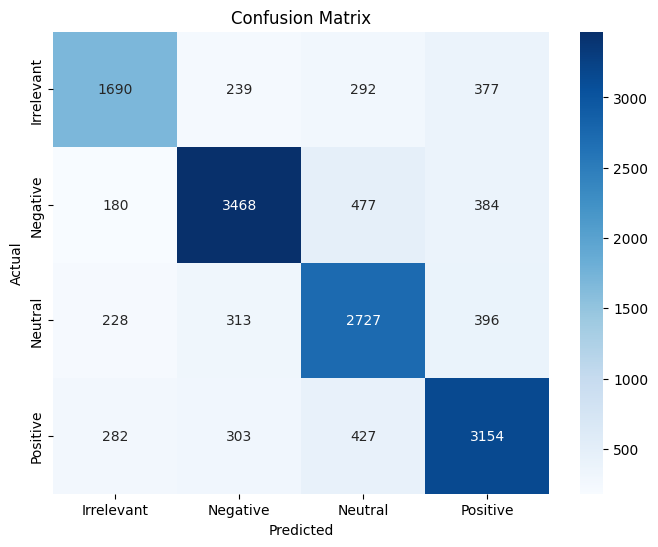

In [44]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=encoder.classes_, yticklabels=encoder.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

---
## 🛠️ One-Time Setup (run in terminal before first use)
```bash
# Apple Silicon (M1/M2/M3) — enables Metal GPU
pip install tensorflow-macos tensorflow-metal

# Intel Mac
pip install --upgrade tensorflow
```

## ⚡ Speed Optimization Summary
| Change | Why it's faster |
|---|---|
| Metal GPU (`tensorflow-metal`) | Offloads compute to Apple GPU |
| Mixed precision (`float16`) | Halves memory bandwidth |
| Removed `recurrent_dropout` | Enables CuDNN/Metal optimized kernel |
| GRU instead of LSTM | Fewer gates → ~30% faster |
| `BATCH_SIZE=256` | Better hardware utilization |
| `tf.data` + `.cache()` + `.prefetch()` | Eliminates Python bottleneck |